In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv("expenses.csv")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df = df.dropna(subset=["Date", "Amount", "Category"])
df = df[df["Amount"] > 0]
df

,Date,Amount,Category,Description
0,2026-01-03,450.0,Food,Groceries
1,2026-01-05,120.0,Transport,Auto fare
2,2026-01-08,800.0,Utilities,Electricity bill
3,2026-01-12,300.0,Entertainment,Movie
4,2026-01-15,650.0,Food,Restaurant
5,2026-01-18,200.0,Transport,Bus pass
6,2026-01-22,900.0,Utilities,Internet bill
7,2026-01-25,250.0,Entertainment,Games
8,2026-02-02,500.0,Food,Groceries
9,2026-02-06,150.0,Transport,Cab


In [3]:
print("Number of Expenses:", len(df))
print("Total Expense: ₹", df["Amount"].sum())
print("\nCategories:")
print(df["Category"].unique())

Number of Expenses: 16
Total Expense: ₹ 7500.0

Categories:
<StringArray>
['Food', 'Transport', 'Utilities', 'Entertainment']
Length: 4, dtype: str


In [4]:
class ExpenseTracker:
    
    def __init__(self, data):
        self.df = data.copy()
    
    def add_expense(self, date, amount, category, description):
        try:
            date = pd.to_datetime(date, format="%Y-%m-%d")
            amount = float(amount)
            if amount <= 0:
                print("Amount must be greater than 0.")
                return          
            valid_categories = [
                "Food",
                "Transport",
                "Utilities",
                "Entertainment"
            ] 
            if category not in valid_categories:
                print("Invalid category.")
                return
            new_expense = {
                "Date": date,
                "Amount": amount,
                "Category": category,
                "Description": description
            }
            self.df.loc[len(self.df)] = new_expense
            print("Expense added successfully!")
        except ValueError:
            print("Invalid input.")

In [5]:
tracker = ExpenseTracker(df)
tracker.df

,Date,Amount,Category,Description
0,2026-01-03,450.0,Food,Groceries
1,2026-01-05,120.0,Transport,Auto fare
2,2026-01-08,800.0,Utilities,Electricity bill
3,2026-01-12,300.0,Entertainment,Movie
4,2026-01-15,650.0,Food,Restaurant
5,2026-01-18,200.0,Transport,Bus pass
6,2026-01-22,900.0,Utilities,Internet bill
7,2026-01-25,250.0,Entertainment,Games
8,2026-02-02,500.0,Food,Groceries
9,2026-02-06,150.0,Transport,Cab


In [6]:
tracker.add_expense(
    "2026-03-01",
    350,
    "Food",
    "Lunch",
)
tracker.df.tail()

Expense added successfully!


,Date,Amount,Category,Description
12,2026-02-18,550.0,Food,Restaurant
13,2026-02-21,180.0,Transport,Bus
14,2026-02-25,1000.0,Utilities,Phone and internet
15,2026-03-01,350.0,Food,Lunch
16,2026-03-01,350.0,Food,Lunch


In [7]:
def get_summary(self):
    if self.df.empty:
        print("No expense data available.")
        return
    amounts = self.df["Amount"].to_numpy()
    total = np.sum(amounts)
    average = np.mean(amounts)
    maximum = np.max(amounts)
    minimum = np.min(amounts)

    print("----- Expense Summary -----")
    print("Total Expense: ₹", total)
    print("Average Expense: ₹", round(average, 2))
    print("Highest Expense: ₹", maximum)
    print("Lowest Expense: ₹", minimum)
    print("\nCategory-wise Expense: ")
    print(self.df.groupby("Category")["Amount"].sum() .sort_values(ascending=False))

ExpenseTracker.get_summary = get_summary

In [8]:
tracker.get_summary()

----- Expense Summary -----
Total Expense: ₹ 7850.0
Average Expense: ₹ 461.76
Highest Expense: ₹ 1000.0
Lowest Expense: ₹ 120.0

Category-wise Expense: 
Category
Utilities        3400.0
Food             2850.0
Entertainment     950.0
Transport         650.0
Name: Amount, dtype: float64


In [9]:
def filter_expenses(self, condition):
    
    if self.df.empty:
        print("No expense data available.")
        return pd.DataFrame()    
    result = self.df.copy()    
    if "category" in condition:
        category = condition["category"]
        result = result[result["Category"].str.lower() == category.lower()]
    if "start_date" in condition:
        start_date = pd.to_datetime(
            condition["start_date"],
            errors="coerce"
        )
        if pd.isna(start_date):
            print("Invalid start date.")
            return pd.DataFrame()
        result = result[result["Date"] >= start_date]
    if "end_date" in condition:
        end_date = pd.to_datetime(
            condition["end_date"],
            errors="coerce"
        )
        if pd.isna(end_date):
            print("Invalid end date.")
            return pd.DataFrame()
        result = result[result["Date"] <= end_date]
    return result.reset_index(drop=True)
ExpenseTracker.filter_expenses = filter_expenses

In [10]:
food_expenses = tracker.filter_expenses({"category": "Food"})

food_expenses

,Date,Amount,Category,Description
0,2026-01-03,450.0,Food,Groceries
1,2026-01-15,650.0,Food,Restaurant
2,2026-02-02,500.0,Food,Groceries
3,2026-02-18,550.0,Food,Restaurant
4,2026-03-01,350.0,Food,Lunch
5,2026-03-01,350.0,Food,Lunch


In [11]:
date_expenses = tracker.filter_expenses({"start_date": "2026-01-01","end_date": "2026-01-31"})

date_expenses

,Date,Amount,Category,Description
0,2026-01-03,450.0,Food,Groceries
1,2026-01-05,120.0,Transport,Auto fare
2,2026-01-08,800.0,Utilities,Electricity bill
3,2026-01-12,300.0,Entertainment,Movie
4,2026-01-15,650.0,Food,Restaurant
5,2026-01-18,200.0,Transport,Bus pass
6,2026-01-22,900.0,Utilities,Internet bill
7,2026-01-25,250.0,Entertainment,Games


In [12]:
def generate_report(self):
    
    if self.df.empty:
        print("No data available.")
        return
    print("=" * 40)
    print("        EXPENSE REPORT")
    print("=" * 40)
    print("Total Expenses:",
          len(self.df))
    print("Total Amount: ₹",
          self.df["Amount"].sum())
    print("Average Amount: ₹",
          round(self.df["Amount"].mean(), 2))
    print("\nCategory-wise Spending:")
    category_total = (
        self.df.groupby("Category")["Amount"]
        .sum()
        .sort_values(ascending=False)
    )
    print(category_total)
    print("\nHighest Spending Category:",
          category_total.idxmax())

ExpenseTracker.generate_report = generate_report

In [13]:
tracker.generate_report()

        EXPENSE REPORT
Total Expenses: 17
Total Amount: ₹ 7850.0
Average Amount: ₹ 461.76

Category-wise Spending:
Category
Utilities        3400.0
Food             2850.0
Entertainment     950.0
Transport         650.0
Name: Amount, dtype: float64

Highest Spending Category: Utilities


In [14]:
monthly_expense = (tracker.df.assign(Month=tracker.df["Date"].dt.to_period("M")).groupby("Month")["Amount"].sum())

monthly_expense

Month
2026-01    3670.0
2026-02    3480.0
2026-03     700.0
Freq: M, Name: Amount, dtype: float64

In [15]:
category_expense = (tracker.df.groupby("Category")["Amount"].sum().sort_values(ascending=False))

category_expense

Category
Utilities        3400.0
Food             2850.0
Entertainment     950.0
Transport         650.0
Name: Amount, dtype: float64

In [16]:
spending_percentage = (category_expense /category_expense.sum()) * 100

spending_percentage.round(2)

Category
Utilities        43.31
Food             36.31
Entertainment    12.10
Transport         8.28
Name: Amount, dtype: float64

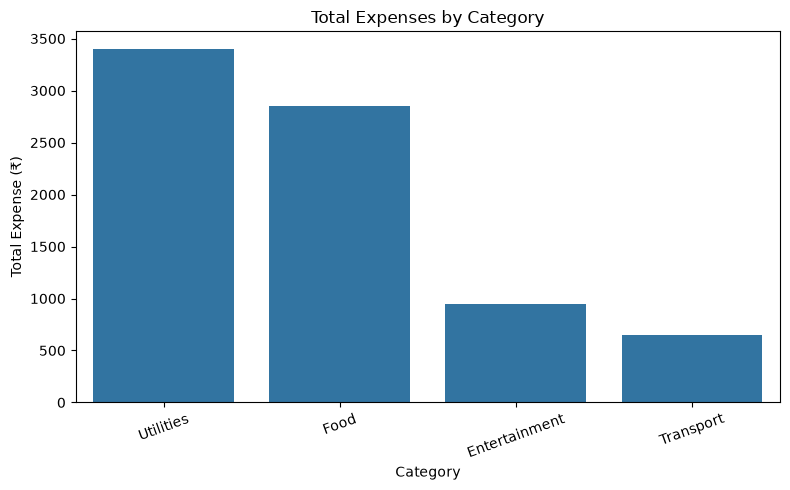

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=category_expense.index,
    y=category_expense.values
)
plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Expense (₹)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

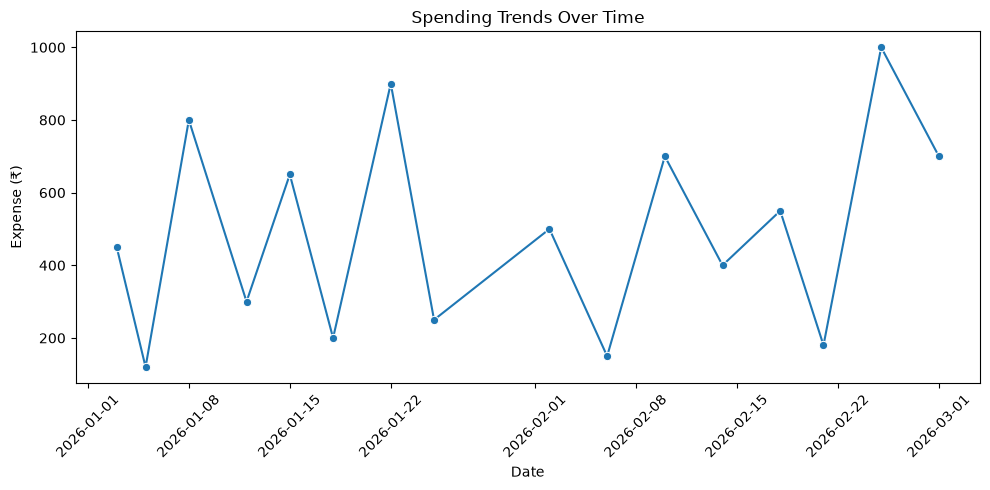

In [18]:
daily_expense = (
    tracker.df.groupby("Date")["Amount"]
    .sum()
    .sort_index()
)
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=daily_expense.index,
    y=daily_expense.values,
    marker="o"
)
plt.title("Spending Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Expense (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

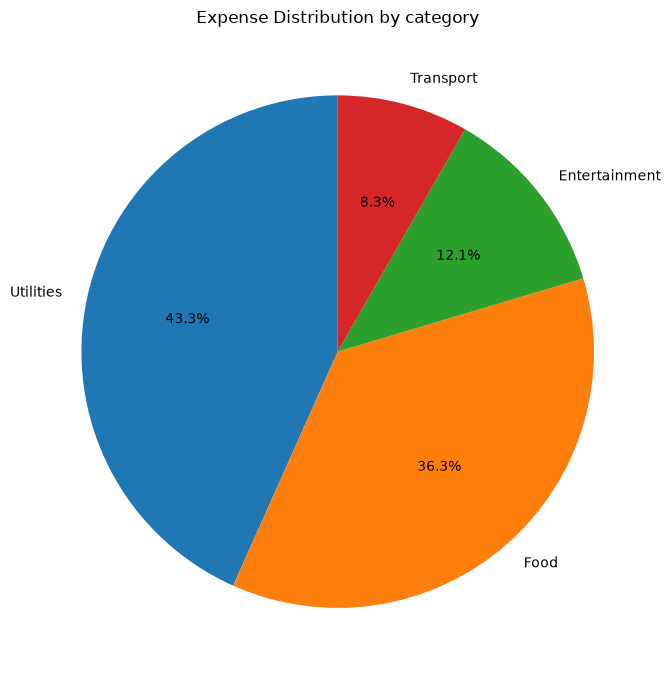

In [19]:
plt.figure(figsize=(7,7))
plt.pie(
    category_expense.values,
    labels=category_expense.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Expense Distribution by category")
plt.tight_layout()
plt.show()

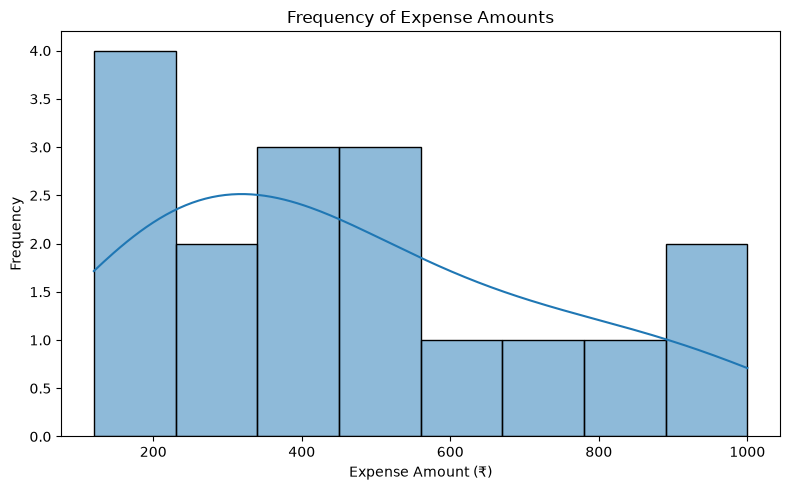

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(
    tracker.df["Amount"],
    bins=8,
    kde=True
)
plt.title("Frequency of Expense Amounts")
plt.xlabel("Expense Amount (₹)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [21]:
highest_expense = tracker.df.loc[tracker.df["Amount"].idxmax()]
print("Highest Expense")
print("----------------")
print("Date:", highest_expense["Date"].date())
print("Amount: ₹", highest_expense["Amount"])
print("Category:", highest_expense["Category"])
print("Description:", highest_expense["Description"])

Highest Expense
----------------
Date: 2026-02-25
Amount: ₹ 1000.0
Category: Utilities
Description: Phone and internet


In [22]:
tracker.df.to_csv("expenes.csv", index=False)
print("Data saved successfully!")

Data saved successfully!


In [23]:
tracker.df

,Date,Amount,Category,Description
0,2026-01-03,450.0,Food,Groceries
1,2026-01-05,120.0,Transport,Auto fare
2,2026-01-08,800.0,Utilities,Electricity bill
3,2026-01-12,300.0,Entertainment,Movie
4,2026-01-15,650.0,Food,Restaurant
5,2026-01-18,200.0,Transport,Bus pass
6,2026-01-22,900.0,Utilities,Internet bill
7,2026-01-25,250.0,Entertainment,Games
8,2026-02-02,500.0,Food,Groceries
9,2026-02-06,150.0,Transport,Cab


In [24]:
def main_menu():
    
    while True: 
        print("\n==============================")
        print("    SMART EXPENSE TRACKER")
        print("==============================")
        
        print("1. View Expenses")
        print("2. Add Expense")
        print("3. Expense Summary")
        print("4. Filter by Category")
        print("5. Filter by Date Range")
        print("6. Generate Report")
        print("7. Monthly Analysis")
        print("8. Show Visualizations")
        print("9. Save Data")
        print("10. Exit")
        
        choice = input("Enter your choice: ")
        if choice == "1":
            print(tracker.df)        
        elif choice == "2":
            try:
                date = input("Enter date (YYYY-MM-DD): ")
                amount = float(input("Enter amount: "))
                category = input("Enter category: ")
                description = input("Enter description: ")                
                tracker.add_expense(
                    date,
                    amount,
                    category,
                    description
                )                
            except ValueError:
                print("Invalid amount.")        
        elif choice == "3":
            tracker.get_summary()        
        elif choice == "4":
            category = input("Enter category: ")            
            result = tracker.filter_expenses({
                "category": category
            })            
            if result.empty:
                print("No expenses found.")
            else:
                print(result)        
        elif choice == "5":
            start = input("Enter start date (YYYY-MM-DD): ")
            end = input("Enter end date (YYYY-MM-DD): ")            
            result = tracker.filter_expenses({
                "start_date": start,
                "end_date": end
            })            
            if result.empty:
                print("No expenses found.")
            else:
                print(result)        
        elif choice == "6":
            tracker.generate_report()        
        elif choice == "7":
            print(monthly_expense)        
        elif choice == "8":
            print("Run Cells 17 to 20 to view all graphs.")        
        elif choice == "9":
            tracker.df.to_csv(
                "expenses.csv",
                index=False
            )
            print("Data saved successfully!")        
        elif choice == "10":
            tracker.df.to_csv(
                "expenses.csv",
                index=False
            )            
            print("Thank you for using Smart Expense Tracker!")
            break        
        else:
            print("Invalid choice. Please enter 1-10.")

In [25]:
main_menu()


    SMART EXPENSE TRACKER
1. View Expenses
2. Add Expense
3. Expense Summary
4. Filter by Category
5. Filter by Date Range
6. Generate Report
7. Monthly Analysis
8. Show Visualizations
9. Save Data
10. Exit


Enter your choice:  1


         Date  Amount       Category            Description
0  2026-01-03   450.0           Food              Groceries
1  2026-01-05   120.0      Transport              Auto fare
2  2026-01-08   800.0      Utilities       Electricity bill
3  2026-01-12   300.0  Entertainment                  Movie
4  2026-01-15   650.0           Food             Restaurant
5  2026-01-18   200.0      Transport               Bus pass
6  2026-01-22   900.0      Utilities          Internet bill
7  2026-01-25   250.0  Entertainment                  Games
8  2026-02-02   500.0           Food              Groceries
9  2026-02-06   150.0      Transport                    Cab
10 2026-02-10   700.0      Utilities  Water and electricity
11 2026-02-14   400.0  Entertainment                 Dinner
12 2026-02-18   550.0           Food             Restaurant
13 2026-02-21   180.0      Transport                    Bus
14 2026-02-25  1000.0      Utilities     Phone and internet
15 2026-03-01   350.0           Food    

Enter your choice:  3


----- Expense Summary -----
Total Expense: ₹ 7850.0
Average Expense: ₹ 461.76
Highest Expense: ₹ 1000.0
Lowest Expense: ₹ 120.0

Category-wise Expense: 
Category
Utilities        3400.0
Food             2850.0
Entertainment     950.0
Transport         650.0
Name: Amount, dtype: float64

    SMART EXPENSE TRACKER
1. View Expenses
2. Add Expense
3. Expense Summary
4. Filter by Category
5. Filter by Date Range
6. Generate Report
7. Monthly Analysis
8. Show Visualizations
9. Save Data
10. Exit


...

Run Cells 17 to 20 to view all graphs.

    SMART EXPENSE TRACKER
1. View Expenses
2. Add Expense
3. Expense Summary
4. Filter by Category
5. Filter by Date Range
6. Generate Report
7. Monthly Analysis
8. Show Visualizations
9. Save Data
10. Exit


Enter your choice:  9


Data saved successfully!

    SMART EXPENSE TRACKER
1. View Expenses
2. Add Expense
3. Expense Summary
4. Filter by Category
5. Filter by Date Range
6. Generate Report
7. Monthly Analysis
8. Show Visualizations
9. Save Data
10. Exit


Enter your choice:  10


Thank you for using Smart Expense Tracker!
